In [1]:
import bldw
import numpy as np
import blimpy as bl
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import setigen as stg
from astropy import units as u
from turbo_seti.find_event.find_event_pipeline import find_event_pipeline
from turbo_seti.find_event.plot_event_pipeline import plot_event_pipeline
import logging
import multiprocessing
%matplotlib inline

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

numexpr.utils   INFO     Note: NumExpr detected 40 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
numexpr.utils   INFO     NumExpr defaulting to 8 threads.


In [2]:
# SEARCH CADENCES:

h5dir = '/datag/public/ATLAS/GB_ATLAS'

h5_list = np.sort(glob.glob(h5dir+'/*.0000.h5'))
print('Number of cadences to search:', len(h5_list)/6)
for h5 in h5_list:
    print(h5)

Number of cadences to search: 72.0
/datag/public/ATLAS/GB_ATLAS/blc20_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.0000.h5
/datag/public/ATLAS/GB_ATLAS/blc20_guppi_61027_31626_DIAG_3I_ATLAS_OFF_0062.rawspec.0000.h5
/datag/public/ATLAS/GB_ATLAS/blc20_guppi_61027_31945_DIAG_3I_ATLAS_0063.rawspec.0000.h5
/datag/public/ATLAS/GB_ATLAS/blc20_guppi_61027_32266_DIAG_3I_ATLAS_OFF_0064.rawspec.0000.h5
/datag/public/ATLAS/GB_ATLAS/blc20_guppi_61027_32588_DIAG_3I_ATLAS_0065.rawspec.0000.h5
/datag/public/ATLAS/GB_ATLAS/blc20_guppi_61027_32906_DIAG_3I_ATLAS_OFF_0066.rawspec.0000.h5
/datag/public/ATLAS/GB_ATLAS/blc21_guppi_61027_17226_DIAG_3I_ATLAS_0013.rawspec.0000.h5
/datag/public/ATLAS/GB_ATLAS/blc21_guppi_61027_17543_DIAG_3I_ATLAS_OFF_0014.rawspec.0000.h5
/datag/public/ATLAS/GB_ATLAS/blc21_guppi_61027_17861_DIAG_3I_ATLAS_0015.rawspec.0000.h5
/datag/public/ATLAS/GB_ATLAS/blc21_guppi_61027_18179_DIAG_3I_ATLAS_OFF_0016.rawspec.0000.h5
/datag/public/ATLAS/GB_ATLAS/blc21_guppi_61027_18497_DIAG_3I_ATLA

In [3]:
outdir = '/datax/scratch/benjb/3I-ATLAS/'

logger = logging.getLogger(__name__)

def process_files(xxx):
    n = xxx[0]
    list_of_h5_files = xxx[1]
    # Remove all handlers associated with the root logger object.
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)
    logging.basicConfig(filename=f'{outdir}000_{n}_051925.log', filemode="a", level=logging.DEBUG)
    for i, file in enumerate(list_of_h5_files):
        # Execute seticore in the terminal
        logger.info(f'Searching #{i+1} of {len(list_of_h5_files)} files ...')
        if 'OFF' in file:
            snr = 3
        else:
            snr = 5
        console = 'CUDA_DEVICE_ORDER=PCI_BUS_ID CUDA_VISIBLE_DEVICES=3 seticore ' + file + ' -M 4 -s ' + str(snr) + ' --output ' + outdir + os.path.basename(file)[:-2] + 'dat'
        os.system(console)

if __name__ == "__main__":
    # Define n sets of files
    batch_size = len(h5_list)//15
    file_sets = [[str(i), h5_list[i*batch_size:(i+1)*batch_size]] for i in range(15)]
    file_sets.append([str(15), h5_list[15*batch_size:]])

    # Create a pool of n processes
    with multiprocessing.Pool(processes=16) as pool:
        # Map the process_files function to each file set
        pool.map(process_files, file_sets)

    print("All files processed.")

All files processed.


In [4]:
full_h5_list = np.copy(h5_list)
full_dat_list = np.sort(glob.glob('/datax/scratch/benjb/3I-ATLAS/*.dat'))

data_loc = '/datax/scratch/benjb/3I-ATLAS/csvs'

logger = logging.getLogger(__name__)

for i in range(int(len(full_h5_list)/6)):

    if i+1 < 49:
        continue

    logger.info(f'Searching #{i+1} of {int(len(full_h5_list)/6)} cadences ...')

    #if i+1 < cutoff:
    #    print('Already searched this file; continuing ...')
    #    continue

    # for each set of 6 files, run FindEvent and PlotEvent

    h5_list = full_h5_list[i*6:(i+1)*6]
    dat_list = full_dat_list[i*6:(i+1)*6]

    stem = os.path.basename(h5_list[0])[:-5]

    csvf_path = f'{data_loc}/{stem}_found_event_table_3.csv'

    h5_list_path = os.path.join(data_loc, f'{stem}_h5_files.lst')
    logger.info(h5_list_path)
    with open(h5_list_path, 'w') as f:
        for h5_path in h5_list:
            logger.info(h5_path)
            f.write(h5_path + '\n')

    dat_list_path = os.path.join(data_loc, f'{stem}_dat_files.lst')
    logger.info(dat_list_path)
    with open(dat_list_path, 'w') as f:
        for dat_path in dat_list:
            logger.info(dat_path)
            f.write(dat_path + '\n')

    find_event_pipeline(dat_list_path, 
                    h5_list_path,
                    #SNR_cut=2,
                    check_zero_drift = True,
                    filter_threshold = 3, 
                    number_in_cadence = len(dat_list),
                    csv_name=csvf_path, 
                    saving=True
                    )
    
    if not os.path.exists(csvf_path):
        logger.info('No event CSV found. Continuing ...')
        continue

    trimmed_event_df = pd.read_csv(csvf_path)
    
    trimmed_event_df.dropna(subset=['in_n_ons'], inplace=True)

    trimmed_event_df.to_csv(f'{data_loc}/{stem}_f3_trimmed.csv')
    tcsvf_path = f'{data_loc}/{stem}_f3_trimmed.csv'
    
    # if len(trimmed_event_df) > 0:
    #     plot_event_pipeline(tcsvf_path, # full path of the CSV file built by find_event_pipeline()
    #             h5_list_path, # full path of text file containing the list of .h5 files
    #             filter_spec='f{}'.format(3), # filter threshold
    #             user_validation=False, # Non-interactive
    #             plot_dir=data_loc+'/pngs/') 

__main__        INFO     Searching #49 of 72 cadences ...
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/csvs/blc62_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.00_h5_files.lst
__main__        INFO     /datag/public/ATLAS/GB_ATLAS/blc62_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.0000.h5
__main__        INFO     /datag/public/ATLAS/GB_ATLAS/blc62_guppi_61027_31626_DIAG_3I_ATLAS_OFF_0062.rawspec.0000.h5
__main__        INFO     /datag/public/ATLAS/GB_ATLAS/blc62_guppi_61027_31945_DIAG_3I_ATLAS_0063.rawspec.0000.h5
__main__        INFO     /datag/public/ATLAS/GB_ATLAS/blc62_guppi_61027_32266_DIAG_3I_ATLAS_OFF_0064.rawspec.0000.h5
__main__        INFO     /datag/public/ATLAS/GB_ATLAS/blc62_guppi_61027_32588_DIAG_3I_ATLAS_0065.rawspec.0000.h5
__main__        INFO     /datag/public/ATLAS/GB_ATLAS/blc62_guppi_61027_32906_DIAG_3I_ATLAS_OFF_0066.rawspec.0000.h5


__main__        INFO     /datax/scratch/benjb/3I-ATLAS/csvs/blc62_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.00_dat_files.lst
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/blc62_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.0000.dat
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/blc62_guppi_61027_31626_DIAG_3I_ATLAS_OFF_0062.rawspec.0000.dat
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/blc62_guppi_61027_31945_DIAG_3I_ATLAS_0063.rawspec.0000.dat
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/blc62_guppi_61027_32266_DIAG_3I_ATLAS_OFF_0064.rawspec.0000.dat
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/blc62_guppi_61027_32588_DIAG_3I_ATLAS_0065.rawspec.0000.dat
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/blc62_guppi_61027_32906_DIAG_3I_ATLAS_OFF_0066.rawspec.0000.dat

===========   BEGINNING FIND_EVENT PIPELINE   ===========

Assuming the first observation is an ON
find_event_pipeline INFO     file=blc62_guppi_61027_31308_DIAG_3I_ATLA

In [3]:
event_csv_list = np.sort(glob.glob('/datax/scratch/benjb/3I-ATLAS/csvs/*_trimmed.csv'))
print(len(event_csv_list))
for i in range(5):
    print(event_csv_list[i])

5
/datax/scratch/benjb/3I-ATLAS/csvs/blc22_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.00_f3_trimmed.csv
/datax/scratch/benjb/3I-ATLAS/csvs/blc23_guppi_61027_17226_DIAG_3I_ATLAS_0013.rawspec.00_f3_trimmed.csv
/datax/scratch/benjb/3I-ATLAS/csvs/blc23_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.00_f3_trimmed.csv
/datax/scratch/benjb/3I-ATLAS/csvs/blc24_guppi_61027_21817_DIAG_3I_ATLAS_0029.rawspec.00_f3_trimmed.csv
/datax/scratch/benjb/3I-ATLAS/csvs/blc25_guppi_61027_17226_DIAG_3I_ATLAS_0013.rawspec.00_f3_trimmed.csv


__main__        INFO     Searching #1 of 5 files:
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/csvs/blc22_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.00_f3_trimmed.csv
__main__        INFO     3 events in this file. Plotting ...
plot_event_pipeline: Opened file /datax/scratch/benjb/3I-ATLAS/csvs/blc22_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.00_f3_trimmed.csv
plot_event_pipeline: file = blc22_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.0000.h5, tstart = 61027.36236111111, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc22_guppi_61027_31626_DIAG_3I_ATLAS_OFF_0062.rawspec.0000.h5, tstart = 61027.36604166667, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc22_guppi_61027_31945_DIAG_3I_ATLAS_0063.rawspec.0000.h5, tstart = 61027.369733796295, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc22_guppi_61027_32266_DIAG_3I_ATLAS_OFF_0064.rawspec.0000.h5, tstart = 61027.373449074075, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc22_gup

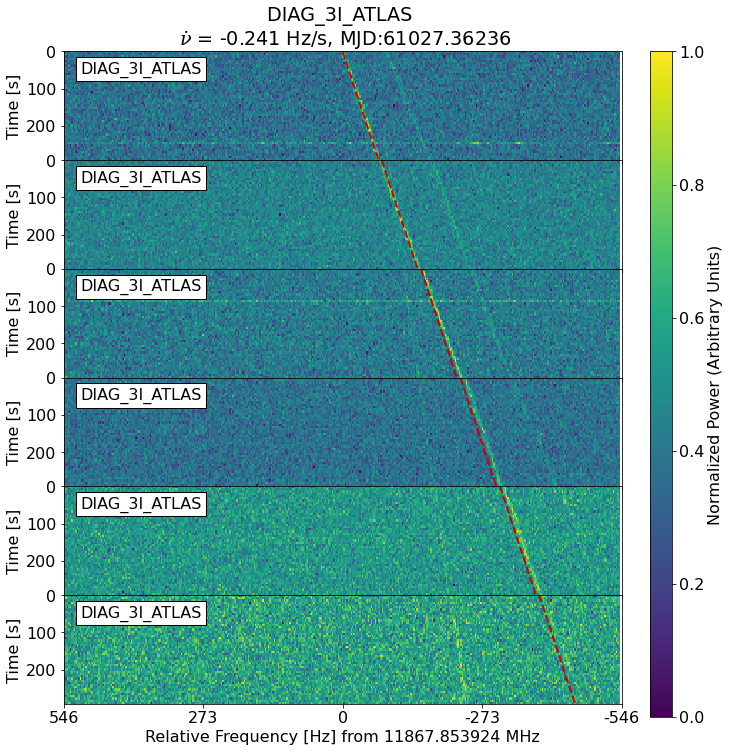

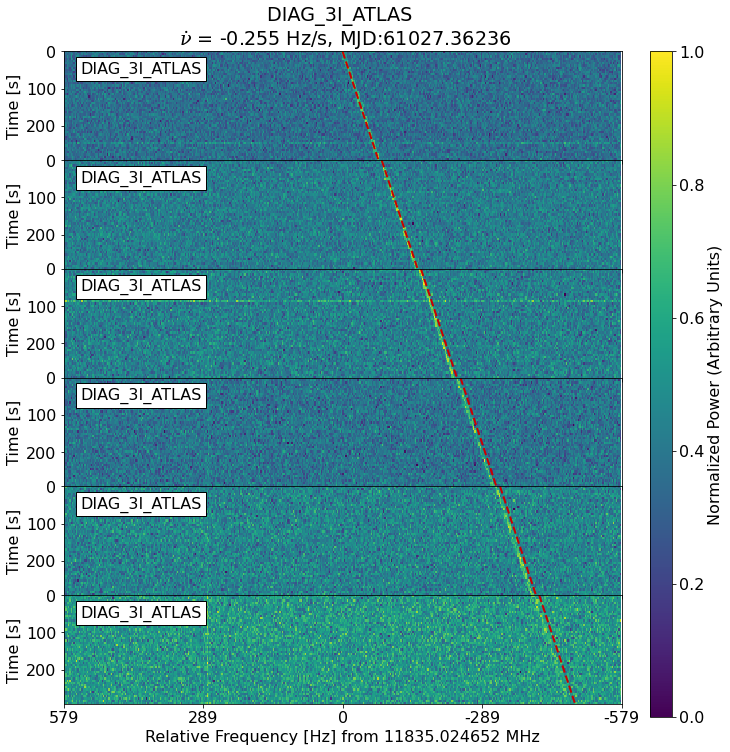

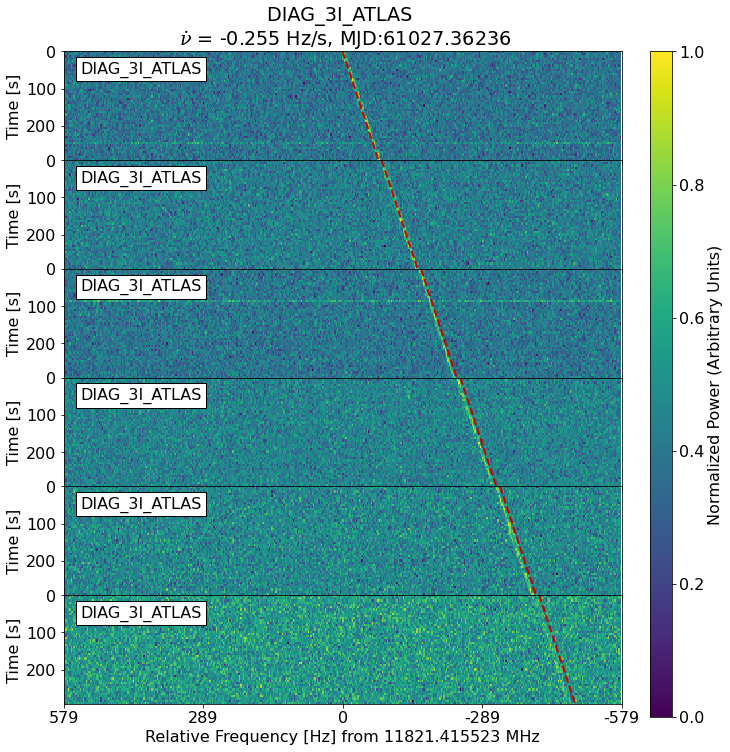

plot_event      INFO     plot_candidate_events: elapsed time = 20.46 seconds
__main__        INFO     Plotting done.
__main__        INFO     Searching #2 of 5 files:
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/csvs/blc23_guppi_61027_17226_DIAG_3I_ATLAS_0013.rawspec.00_f3_trimmed.csv
__main__        INFO     4 events in this file. Plotting ...
plot_event_pipeline: Opened file /datax/scratch/benjb/3I-ATLAS/csvs/blc23_guppi_61027_17226_DIAG_3I_ATLAS_0013.rawspec.00_f3_trimmed.csv
plot_event_pipeline: file = blc23_guppi_61027_17226_DIAG_3I_ATLAS_0013.rawspec.0000.h5, tstart = 61027.199375, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc23_guppi_61027_17543_DIAG_3I_ATLAS_OFF_0014.rawspec.0000.h5, tstart = 61027.203043981484, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc23_guppi_61027_17861_DIAG_3I_ATLAS_0015.rawspec.0000.h5, tstart = 61027.206724537034, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc23_guppi_61027_18179_DIAG_3I_ATLAS_OFF_001

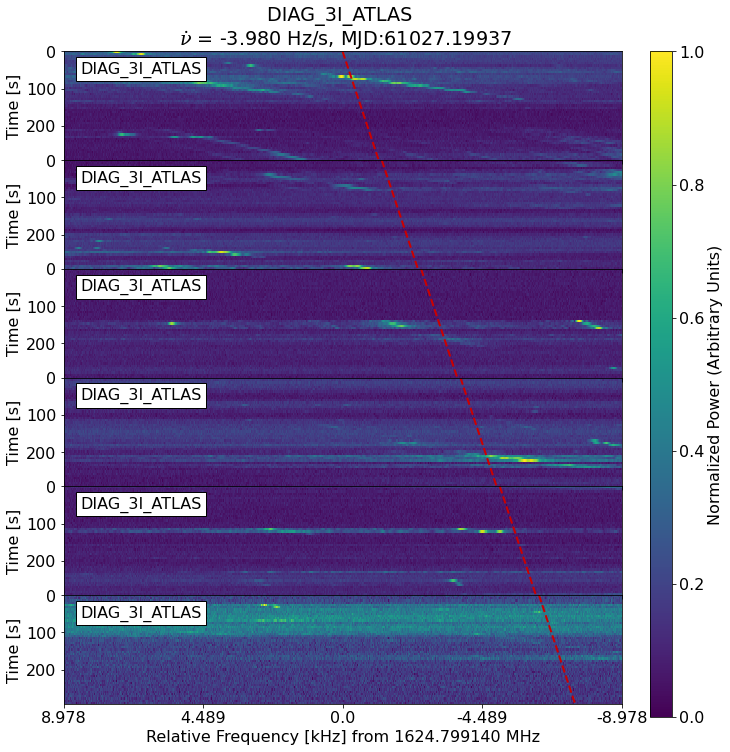

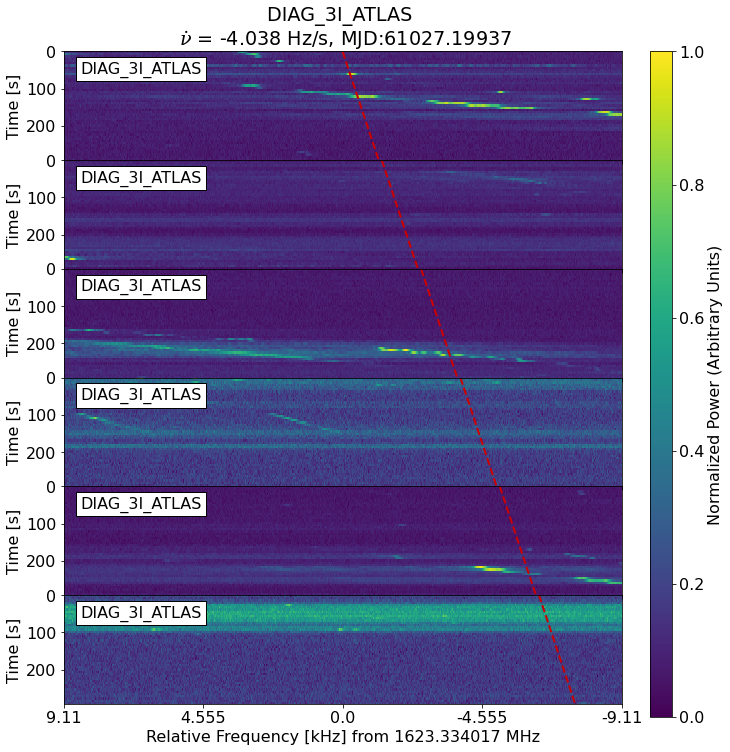

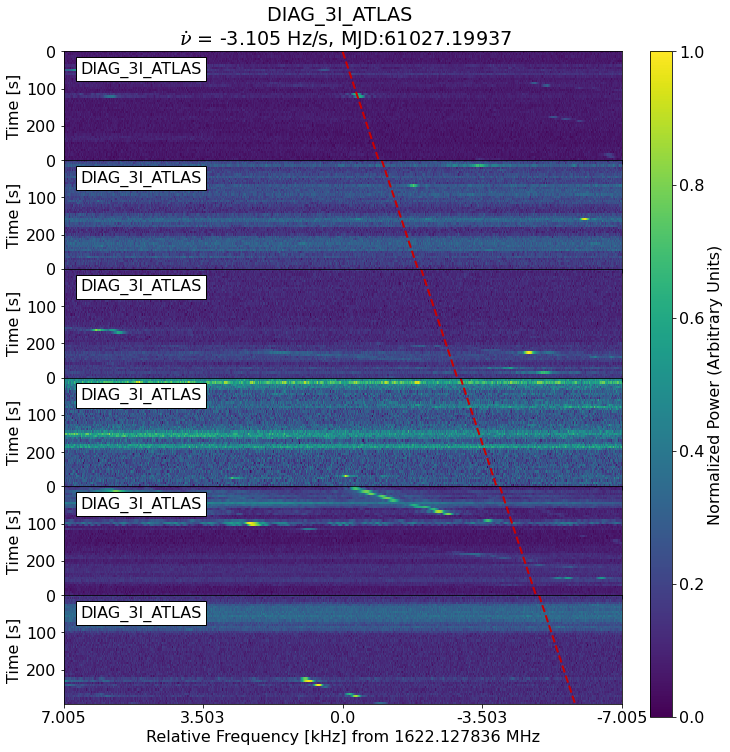

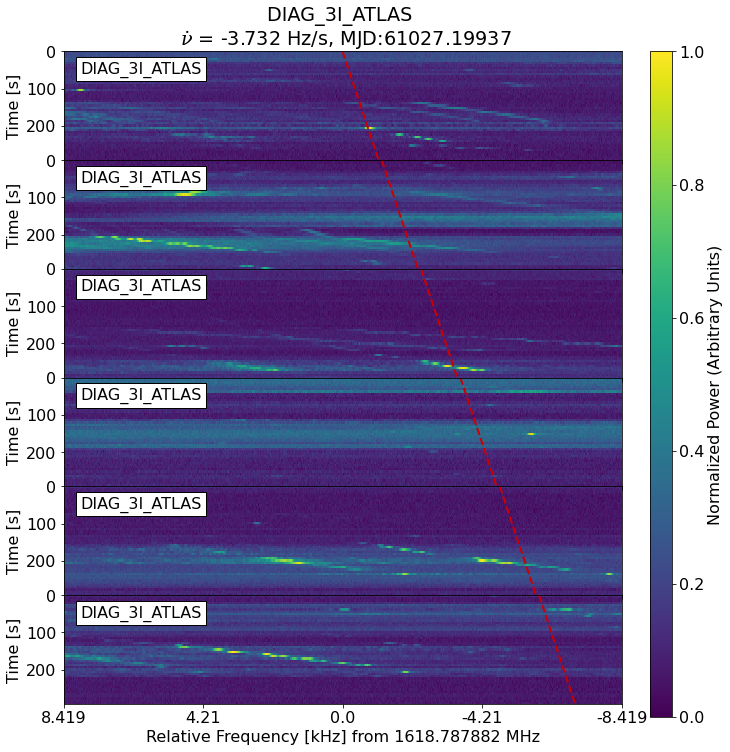

plot_event      INFO     plot_candidate_events: elapsed time = 26.80 seconds
__main__        INFO     Plotting done.
__main__        INFO     Searching #3 of 5 files:
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/csvs/blc23_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.00_f3_trimmed.csv
__main__        INFO     4 events in this file. Plotting ...
plot_event_pipeline: Opened file /datax/scratch/benjb/3I-ATLAS/csvs/blc23_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.00_f3_trimmed.csv
plot_event_pipeline: file = blc23_guppi_61027_31308_DIAG_3I_ATLAS_0061.rawspec.0000.h5, tstart = 61027.36236111111, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc23_guppi_61027_31626_DIAG_3I_ATLAS_OFF_0062.rawspec.0000.h5, tstart = 61027.36604166667, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc23_guppi_61027_31945_DIAG_3I_ATLAS_0063.rawspec.0000.h5, tstart = 61027.369733796295, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc23_guppi_61027_32266_DIAG_3I_ATLAS_OFF

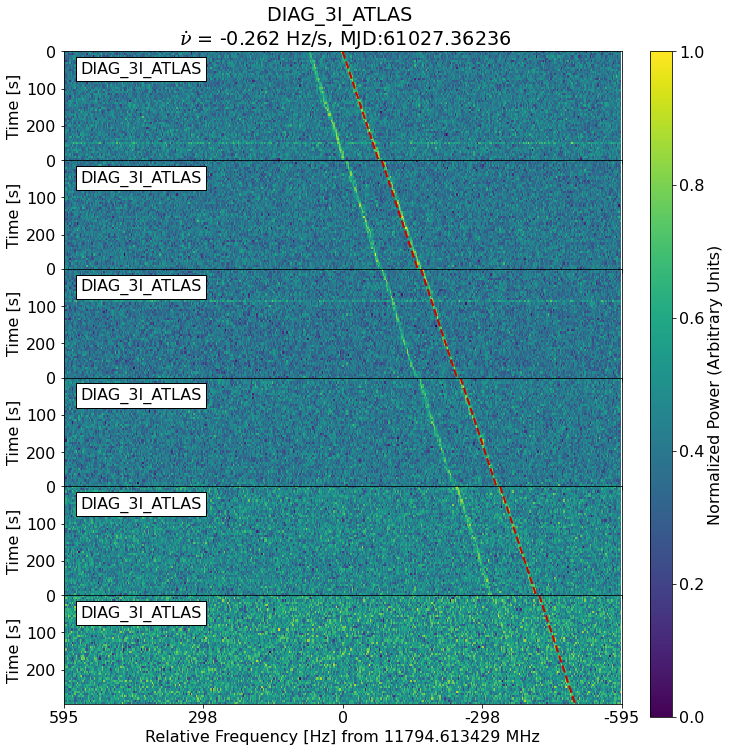

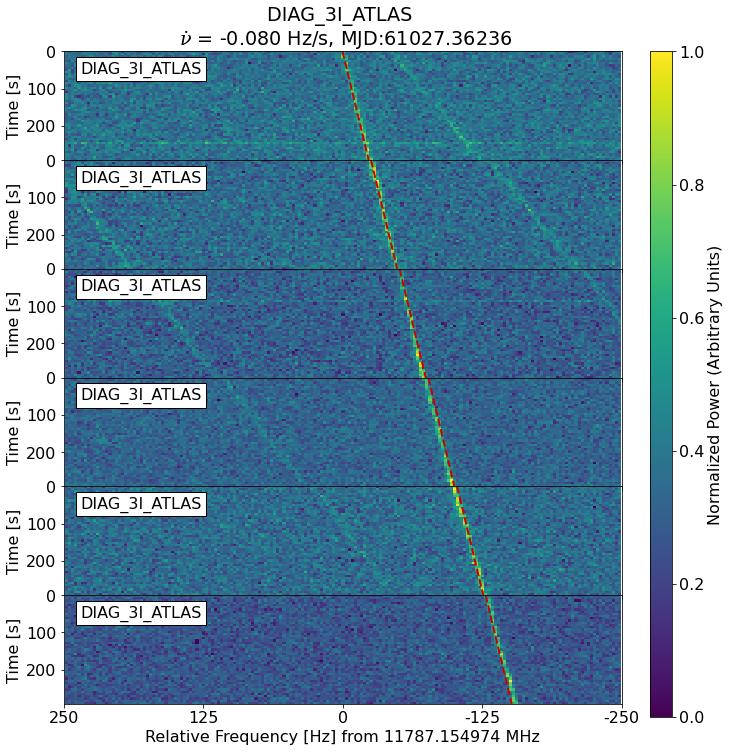

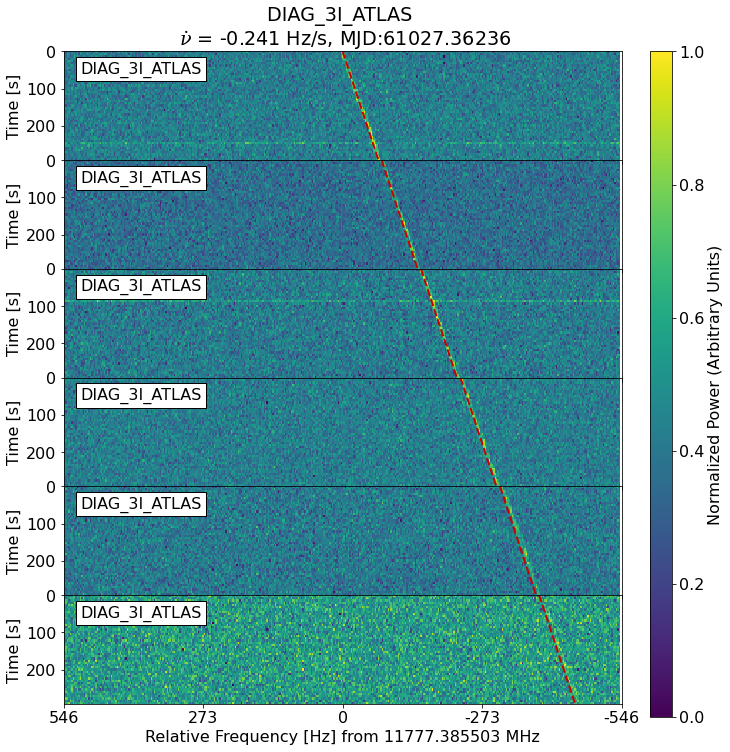

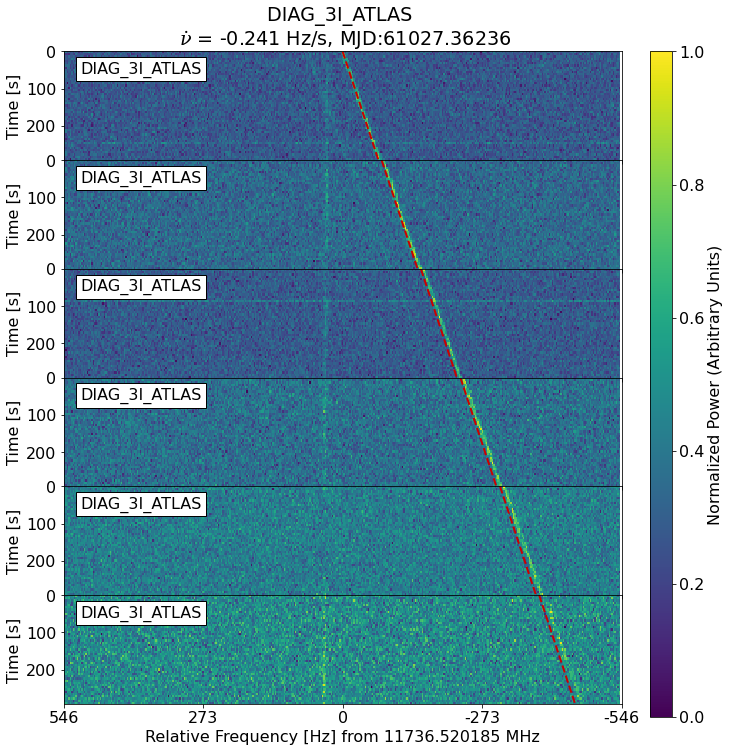

plot_event      INFO     plot_candidate_events: elapsed time = 26.81 seconds
__main__        INFO     Plotting done.
__main__        INFO     Searching #4 of 5 files:
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/csvs/blc24_guppi_61027_21817_DIAG_3I_ATLAS_0029.rawspec.00_f3_trimmed.csv
__main__        INFO     4 events in this file. Plotting ...
plot_event_pipeline: Opened file /datax/scratch/benjb/3I-ATLAS/csvs/blc24_guppi_61027_21817_DIAG_3I_ATLAS_0029.rawspec.00_f3_trimmed.csv
plot_event_pipeline: file = blc24_guppi_61027_21817_DIAG_3I_ATLAS_0029.rawspec.0000.h5, tstart = 61027.25251157407, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc24_guppi_61027_22134_DIAG_3I_ATLAS_OFF_0030.rawspec.0000.h5, tstart = 61027.25618055555, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc24_guppi_61027_22452_DIAG_3I_ATLAS_0031.rawspec.0000.h5, tstart = 61027.25986111111, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc24_guppi_61027_22769_DIAG_3I_ATLAS_OFF_

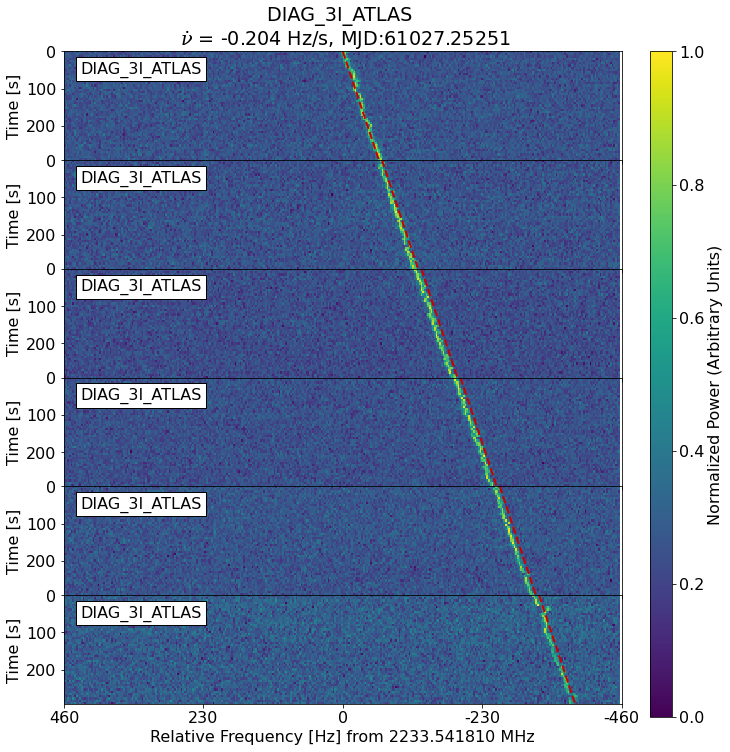

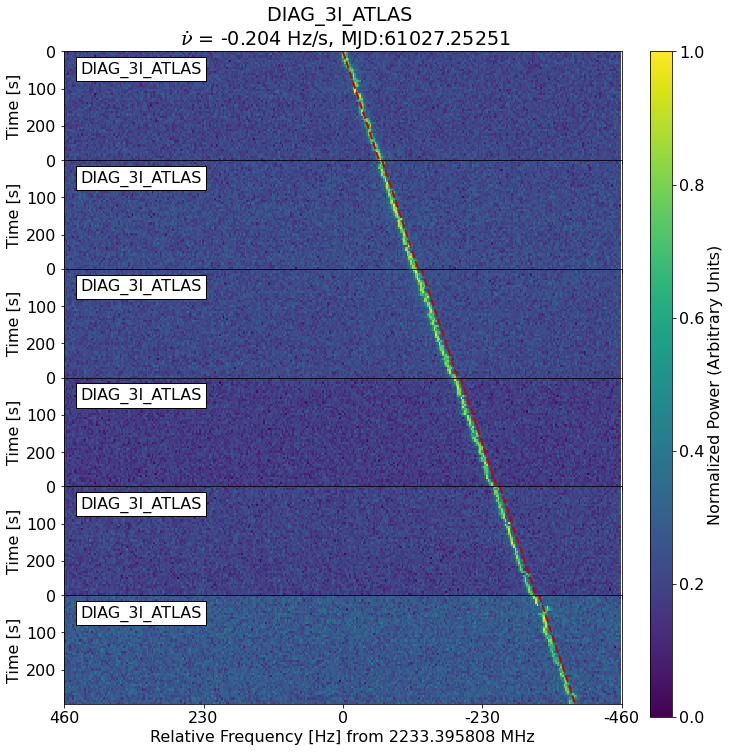

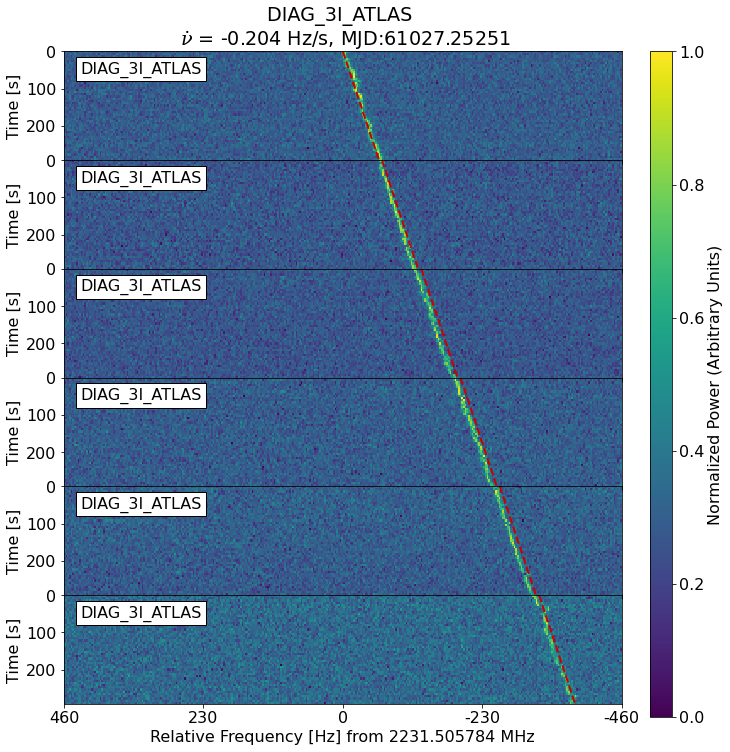

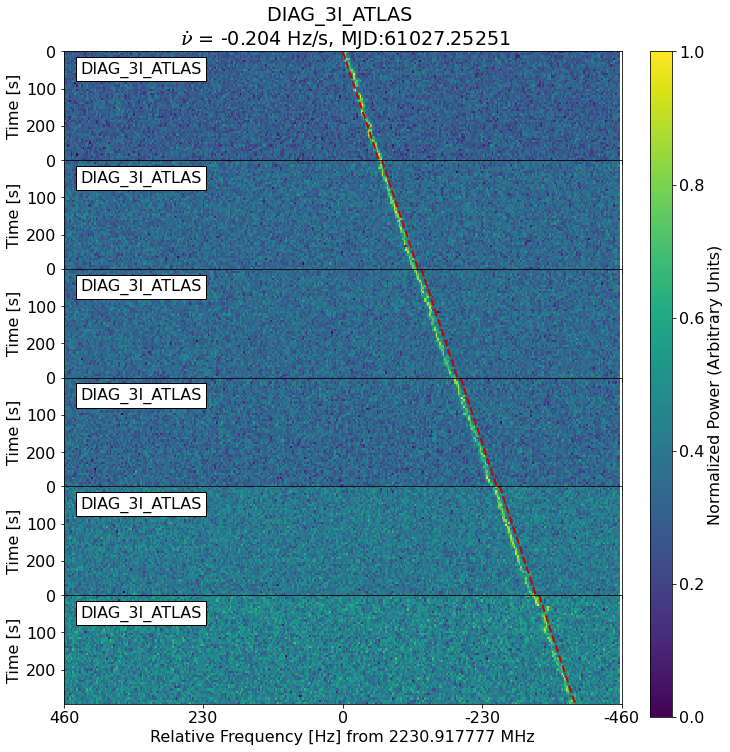

plot_event      INFO     plot_candidate_events: elapsed time = 26.68 seconds
__main__        INFO     Plotting done.
__main__        INFO     Searching #5 of 5 files:
__main__        INFO     /datax/scratch/benjb/3I-ATLAS/csvs/blc25_guppi_61027_17226_DIAG_3I_ATLAS_0013.rawspec.00_f3_trimmed.csv
__main__        INFO     2 events in this file. Plotting ...
plot_event_pipeline: Opened file /datax/scratch/benjb/3I-ATLAS/csvs/blc25_guppi_61027_17226_DIAG_3I_ATLAS_0013.rawspec.00_f3_trimmed.csv
plot_event_pipeline: file = blc25_guppi_61027_17226_DIAG_3I_ATLAS_0013.rawspec.0000.h5, tstart = 61027.199375, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc25_guppi_61027_17543_DIAG_3I_ATLAS_OFF_0014.rawspec.0000.h5, tstart = 61027.203043981484, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc25_guppi_61027_17861_DIAG_3I_ATLAS_0015.rawspec.0000.h5, tstart = 61027.206724537034, source_name = DIAG_3I_ATLAS
plot_event_pipeline: file = blc25_guppi_61027_18179_DIAG_3I_ATLAS_OFF_001

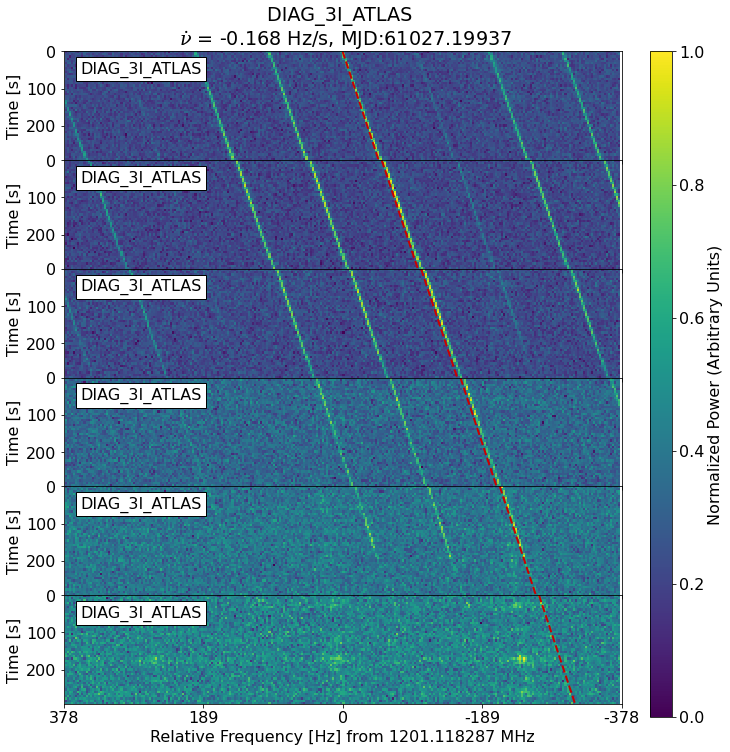

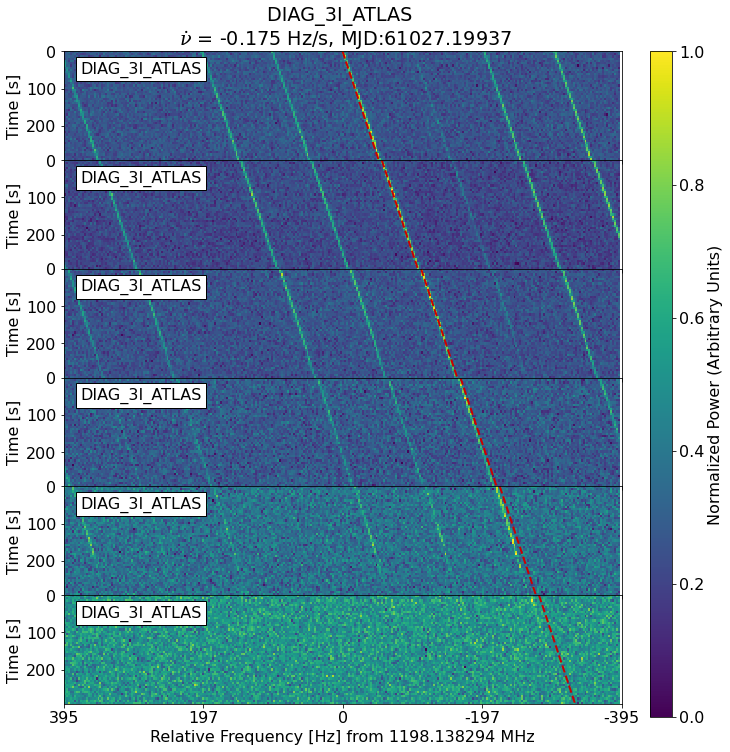

plot_event      INFO     plot_candidate_events: elapsed time = 13.50 seconds
__main__        INFO     Plotting done.


In [6]:
logger = logging.getLogger(__name__)

for i, csv in enumerate(event_csv_list):

    logger.info(f'Searching #{i+1} of {len(event_csv_list)} files:')
    logger.info(f'{csv}')


    h5_loc = '/datax/scratch/benjb/3I-ATLAS/csvs/'
    file_base = os.path.basename(csv).split('f3_trimmed')[0]

    #print(file_base)

    h5_list_path = h5_loc + file_base + 'h5_files.lst'

    df = pd.read_csv(csv)
    if len(df) == 0:
        logger.info('No events to plot in this file.')
        continue
    if len(df) > 100:
        logger.info(f'Too many events ({len(df)}) to plot in this file. Come back later!')
        continue

    logger.info(f'{len(df)} events in this file. Plotting ...')

    #if not os.path.exists(h5_list_path):
    #    print('DNE:', h5_list_path)

    plot_event_pipeline(csv, # full path of the CSV file built by find_event_pipeline()
                        h5_list_path, # full path of text file containing the list of .h5 files
                        filter_spec='f{}'.format(3), # filter threshold
                        user_validation=False, # Non-interactive
                        plot_dir='/datax/scratch/benjb/3I-ATLAS/pngs/')
    
    logger.info(f'Plotting done.')